# Method 6 — Attribute Filtering / Connected-Component Shape Filtering

**Pipeline**
```
CT image
→ global / adaptive threshold
→ connected components
→ remove components based on:
    – area
    – eccentricity
    – major / minor axis ratio
    – circularity
    – skeleton length
→ binary mask  (0 = background, 255 = crack)
```

This directly addresses the problem: **bright spots are round/small, while cracks are elongated/connected.**  
No learning or labels are needed — purely shape-based post-threshold filtering.

*"Shape-attribute-based unsupervised segmentation."*

## Configuration

In [12]:
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
SAMPLES_DIR = Path("../samples")
OUTPUT_DIR  = Path("output/method6_attribute_filtering")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Background subtraction (white top-hat pre-processing) ─────────────────
# A morphological opening with a large disk SE estimates the slowly-varying
# background (the sample disc).  Subtracting it isolates local bright
# features (cracks) and removes the large-scale disc gradient that would
# otherwise make Otsu threshold the whole disc as one blob.
BG_DISK_RADIUS = 15   # pixels — set larger than crack width, smaller than disc

# ── Thresholding (applied to the background-subtracted image) ──────────────
THRESHOLD_METHOD = "otsu"      # "otsu" | "adaptive"
ADAPTIVE_BLOCK   = 51          # block size for adaptive threshold (must be odd)

# ── Shape filters (set to None to disable a criterion) ────────────────────
# Minimum area in pixels — remove tiny specks
MIN_AREA = 50

# Eccentricity in [0, 1]: 0 = circle, 1 = line.
# Cracks are elongated → high eccentricity.
MIN_ECCENTRICITY = 0.90

# Major / minor axis ratio — another measure of elongation.
MIN_AXIS_RATIO = 3.0

# Circularity = 4π·area / perimeter².  Circle = 1, elongated → 0.
# Cracks have low circularity.
MAX_CIRCULARITY = 0.4

# Minimum skeleton (medial axis) length in pixels.
# Long thin branches → likely crack; short → noise blob.
MIN_SKELETON_LENGTH = 15

print("Configuration loaded.")

Configuration loaded.


## Imports

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, img_as_float
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu, threshold_local
from skimage.measure import label, regionprops
from skimage.morphology import skeletonize, opening, disk

print("Imports OK.")

Imports OK.


## Pipeline functions

In [14]:
def load_grayscale(path: Path) -> np.ndarray:
    """Load image as float64 grayscale in [0, 1]."""
    img = io.imread(str(path))
    if img.ndim == 3:
        img = rgb2gray(img)
    return img_as_float(img)


def subtract_background(img: np.ndarray) -> np.ndarray:
    """White top-hat with a large disk SE to isolate local bright features.

    background = morphological_opening(img, disk(BG_DISK_RADIUS))
    residual   = img - background   (clipped to [0, 1])

    This removes the slowly-varying background (the bright sample disc)
    and highlights locally bright structures (cracks) so that a global
    threshold can then find crack pixels rather than the whole disc.
    """
    bg = opening(img, footprint=disk(BG_DISK_RADIUS))
    return np.clip(img - bg, 0, 1)


def binarize(residual: np.ndarray) -> np.ndarray:
    """Threshold the background-subtracted image."""
    if THRESHOLD_METHOD == "otsu":
        return residual > threshold_otsu(residual)
    elif THRESHOLD_METHOD == "adaptive":
        return residual > threshold_local(residual, block_size=ADAPTIVE_BLOCK, method="gaussian")
    else:
        raise ValueError(f"Unknown threshold method: {THRESHOLD_METHOD!r}")


def circularity(prop) -> float:
    """Compute circularity = 4π·area / perimeter².
    Returns 0 if perimeter is 0 (degenerate component).
    """
    if prop.perimeter == 0:
        return 0.0
    return (4 * np.pi * prop.area) / (prop.perimeter ** 2)


def attribute_filter(binary: np.ndarray) -> np.ndarray:
    """Label connected components and keep only crack-like ones.

    A component is kept if it passes ALL enabled shape criteria:
      - area          >= MIN_AREA
      - eccentricity  >= MIN_ECCENTRICITY   (elongated, not circular)
      - axis ratio    >= MIN_AXIS_RATIO     (major / minor)
      - circularity   <= MAX_CIRCULARITY    (not round)
      - skeleton len  >= MIN_SKELETON_LENGTH
    """
    labeled = label(binary)
    out = np.zeros_like(binary, dtype=bool)

    for prop in regionprops(labeled):
        # ── area ──────────────────────────────────────────────────────────
        if MIN_AREA is not None and prop.area < MIN_AREA:
            continue

        # ── eccentricity ───────────────────────────────────────────────────
        if MIN_ECCENTRICITY is not None and prop.eccentricity < MIN_ECCENTRICITY:
            continue

        # ── major / minor axis ratio ───────────────────────────────────────
        if MIN_AXIS_RATIO is not None:
            if prop.minor_axis_length == 0:
                continue
            if prop.major_axis_length / prop.minor_axis_length < MIN_AXIS_RATIO:
                continue

        # ── circularity ────────────────────────────────────────────────────
        if MAX_CIRCULARITY is not None and circularity(prop) > MAX_CIRCULARITY:
            continue

        # ── skeleton length ────────────────────────────────────────────────
        if MIN_SKELETON_LENGTH is not None:
            component_mask = labeled == prop.label
            skel = skeletonize(component_mask)
            if skel.sum() < MIN_SKELETON_LENGTH:
                continue

        out[labeled == prop.label] = True

    return out


def save_mask(mask: np.ndarray, out_path: Path) -> None:
    """Save boolean mask as 8-bit PNG (0 = background, 255 = crack)."""
    out_path.parent.mkdir(parents=True, exist_ok=True)
    io.imsave(str(out_path), (mask.astype(np.uint8)) * 255, check_contrast=False)


print("Functions defined.")

Functions defined.


## Run predictions on all samples

In [15]:
exts   = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
images = sorted(p for p in SAMPLES_DIR.iterdir() if p.suffix.lower() in exts)

print(f"BG disk radius   : {BG_DISK_RADIUS} px")
print(f"Threshold        : {THRESHOLD_METHOD}")
print(f"Min area         : {MIN_AREA}")
print(f"Min eccentricity : {MIN_ECCENTRICITY}")
print(f"Min axis ratio   : {MIN_AXIS_RATIO}")
print(f"Max circularity  : {MAX_CIRCULARITY}")
print(f"Min skeleton len : {MIN_SKELETON_LENGTH}")
print(f"Output dir       : {OUTPUT_DIR.resolve()}")
print(f"Images           : {len(images)}\n")

for img_path in images:
    print(f"  {img_path.name} ...", end=" ", flush=True)
    img      = load_grayscale(img_path)
    residual = subtract_background(img)
    binary   = binarize(residual)
    mask     = attribute_filter(binary)
    out_path = OUTPUT_DIR / (img_path.stem + "_mask.png")
    save_mask(mask, out_path)
    print(f"-> {out_path.name}")

print("\nDone.")

BG disk radius   : 15 px
Threshold        : otsu
Min area         : 50
Min eccentricity : 0.9
Min axis ratio   : 3.0
Max circularity  : 0.4
Min skeleton len : 15
Output dir       : /Users/ramyar/Git/Realistic_Crack/Unsupervised methods/output/method6_attribute_filtering
Images           : 12

  front_0263_1A_220kv.png ... -> front_0263_1A_220kv_mask.png
  front_1100_3A_135kv.png ... -> front_1100_3A_135kv_mask.png
  front_1208_3A_220kv.png ... -> front_1208_3A_220kv_mask.png
  front_1210_1B_135kv.png ... -> front_1210_1B_135kv_mask.png
  front_1274_4A_135kv.png ... -> front_1274_4A_135kv_mask.png
  front_1629_1B_220kv.png ... -> front_1629_1B_220kv_mask.png
  front_1688_2B_220kv.png ... -> front_1688_2B_220kv_mask.png
  front_1851_2A_220kv.png ... -> front_1851_2A_220kv_mask.png
  front_2203_4A_220kv.png ... -> front_2203_4A_220kv_mask.png
  front_2265_2B_135kv.png ... -> front_2265_2B_135kv_mask.png
  front_2402_2A_135kv.png ... -> front_2402_2A_135kv_mask.png
  front_4292_6.png ... -

## Visual inspection — image | raw threshold | before filtering | after filtering

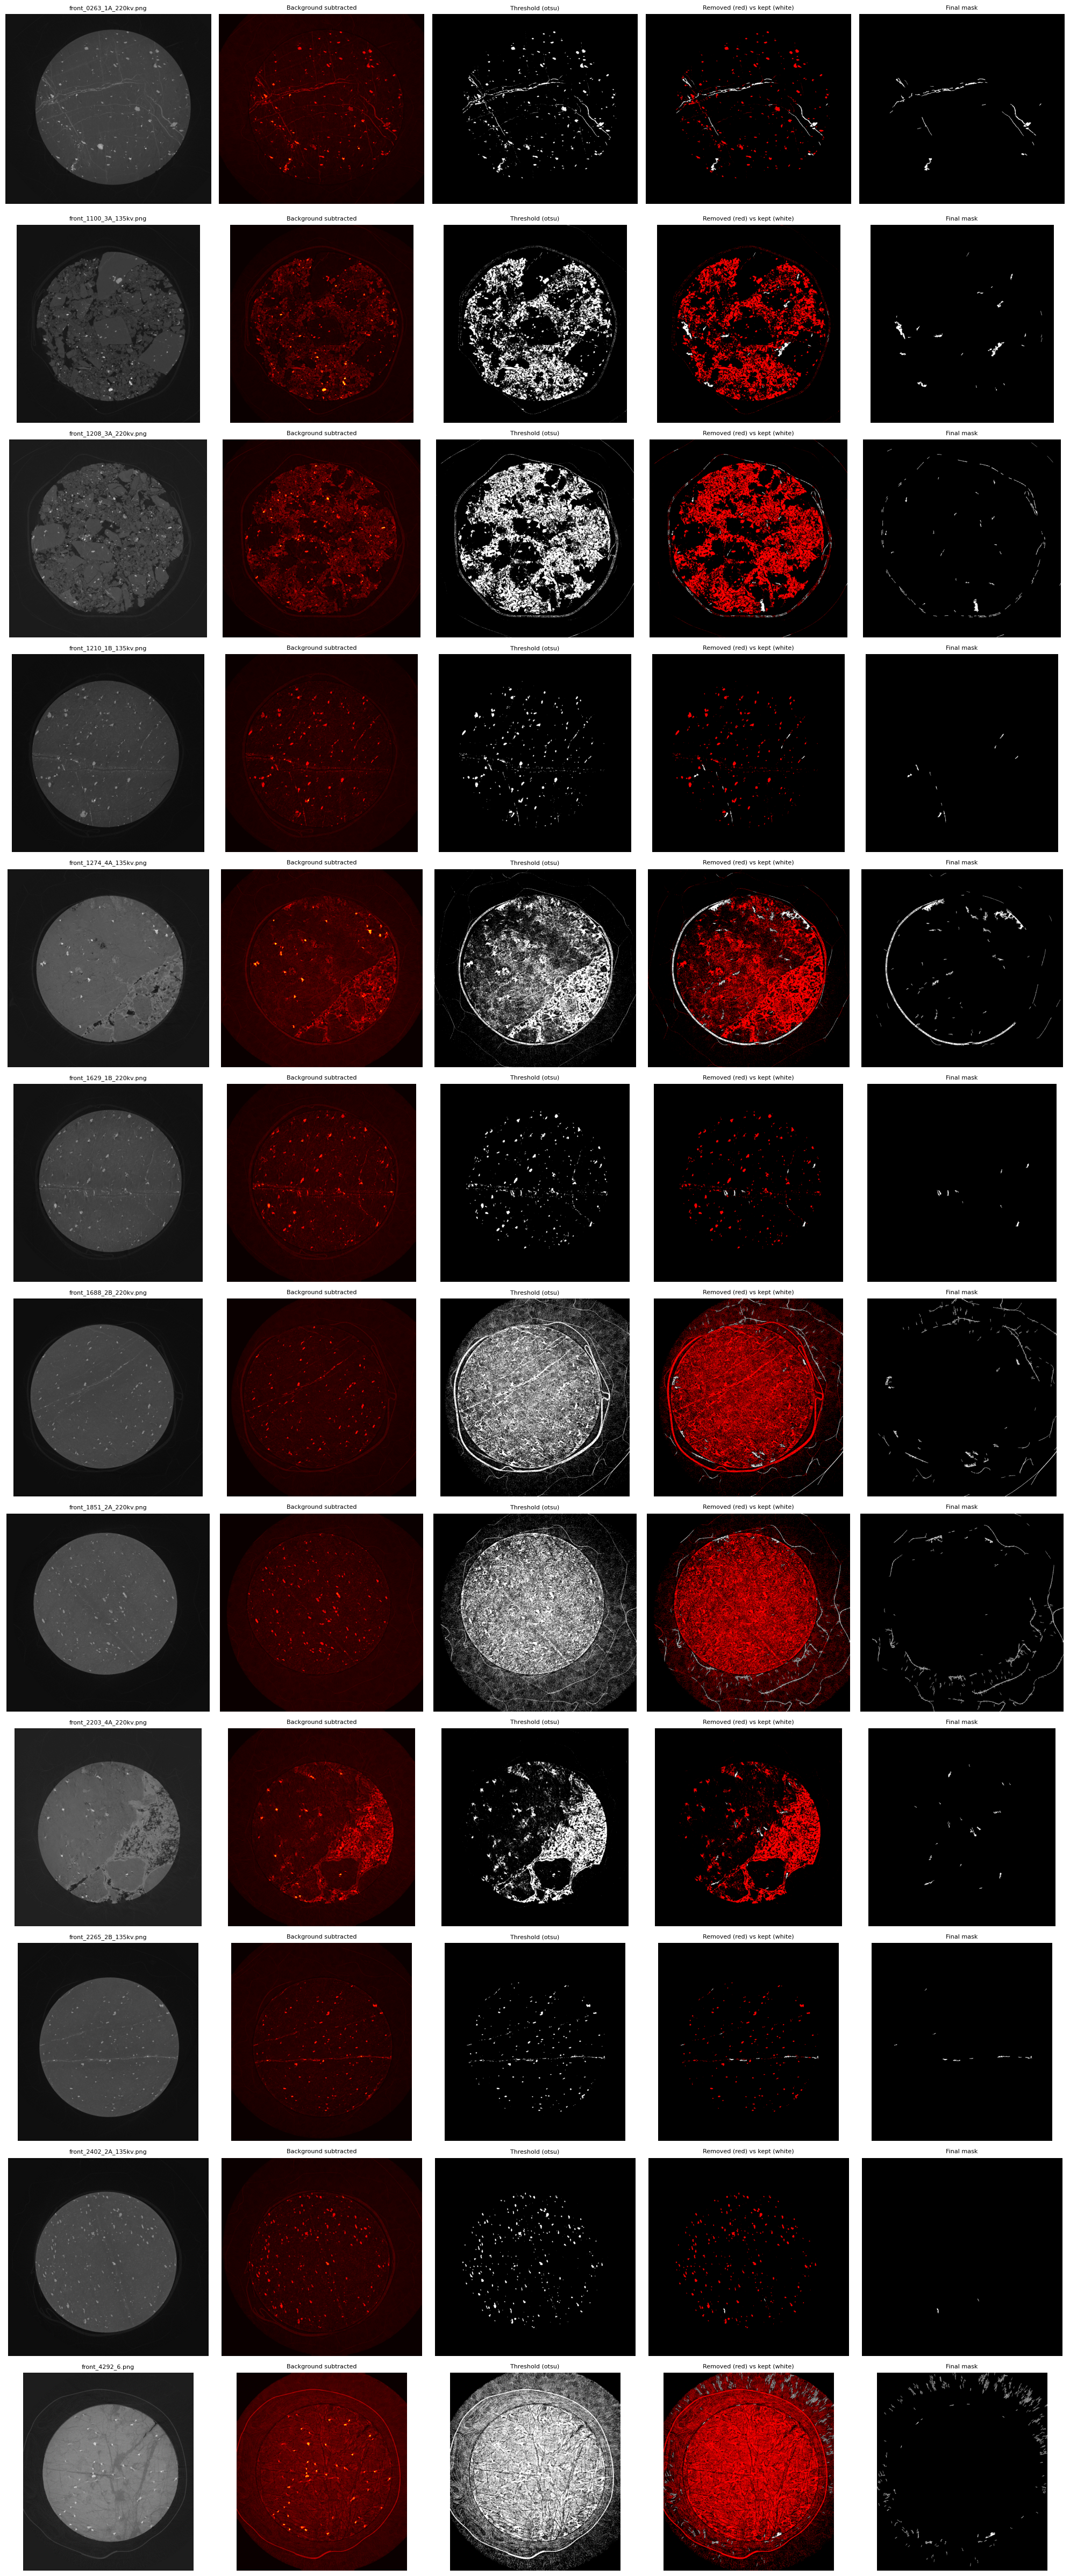

In [10]:
fig, axes = plt.subplots(len(images), 5, figsize=(20, 4 * len(images)))
if len(images) == 1:
    axes = [axes]

for ax_row, img_path in zip(axes, images):
    img      = load_grayscale(img_path)
    residual = subtract_background(img)
    binary   = binarize(residual)
    mask     = attribute_filter(binary)

    ax_row[0].imshow(img, cmap="gray")
    ax_row[0].set_title(img_path.name, fontsize=8)
    ax_row[0].axis("off")

    ax_row[1].imshow(residual, cmap="hot")
    ax_row[1].set_title("Background subtracted", fontsize=8)
    ax_row[1].axis("off")

    ax_row[2].imshow(binary, cmap="gray")
    ax_row[2].set_title(f"Threshold ({THRESHOLD_METHOD})", fontsize=8)
    ax_row[2].axis("off")

    # Show removed components in red so the effect of filtering is clear
    overlay = np.zeros((*binary.shape, 3))
    overlay[binary]         = [1, 1, 1]
    overlay[binary & ~mask] = [1, 0, 0]   # removed: red
    ax_row[3].imshow(overlay)
    ax_row[3].set_title("Removed (red) vs kept (white)", fontsize=8)
    ax_row[3].axis("off")

    ax_row[4].imshow(mask, cmap="gray")
    ax_row[4].set_title("Final mask", fontsize=8)
    ax_row[4].axis("off")

plt.tight_layout()
plt.show()